# PPO + Precedence Network — CliffWalking-v1

Trains **PPO** (same architecture as `ppo_agent.py` baseline) using the frozen
World Model (Precedence Network) to **verify actions BEFORE execution**.

✅ Same PPO as baseline: separate Actor/Critic, GAE-λ (scipy lfilter), KL early stopping  
✅ Tests all 3 World Model configurations:
- **Config 1** : S(t+1) direct  
- **Config 2** : S(t+2) — 2-step lookahead (n=2, less compounding error than n=5)  
- **Config 3** : ΔS one-hot delta

✅ Same `ActionVerifier` as DQN CliffWalking version:
- **Safety check** : predicted next cell ∉ cliff set {37…46}
- **Lookahead check** : k-step greedy simulation — detects cliff-adjacent traps

✅ Rich evaluation: reward, cliff rate, goal rate, steps-to-goal, grid heatmaps,
   verification statistics

## 1. Imports & Setup

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import gymnasium as gym
from gymnasium.wrappers import TimeLimit
import scipy.signal
import random
import json
from datetime import datetime


ENV_NAME        = "CliffWalking-v1"
DATA_PATH       = "../data/collected/CliffWalking"
CHECKPOINT_DIR  = "checkpoints_ppo_precedence_CliffWalking"
PLOT_DIR        = "plots_ppo_precedence_CliffWalking"
WORLD_MODEL_DIR = "world_model/checkpoints_CliffWalking"


GRID_ROWS  = 4
GRID_COLS  = 12
N_STATES   = 48
N_ACTIONS  = 4          
STATE_DIM  = N_STATES   
ACTION_DIM = N_ACTIONS
N_STEP_CONFIG2 = 2   

CLIFF_CELLS = set(range(37, 47))
GOAL_CELL   = 47
START_CELL  = 36


STEPS_PER_EPOCH         = 4_000
EPOCHS                  = 80
HIDDEN_SIZES            = (64, 64)
POLICY_LR               = 3e-4
VALUE_LR                = 1e-3
TRAIN_POLICY_ITERS      = 80
TRAIN_VALUE_ITERS       = 80
GAMMA                   = 0.99
LAM                     = 0.97
CLIP_RATIO              = 0.2
TARGET_KL               = 0.01
ENTROPY_COEF            = 0.05  
MAX_STEPS_PER_EP        = 200   

SEED   = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR,       exist_ok=True)

np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

print(f" Setup OK")
print(f"  Device      : {DEVICE}")
print(f"  Environment : {ENV_NAME}  ({N_STATES} states, {N_ACTIONS} actions)")
print(f"  Cliff cells : {sorted(CLIFF_CELLS)}")
print(f"  Config 2    : n_step={N_STEP_CONFIG2}")
print(f"  steps/epoch={STEPS_PER_EPOCH} | epochs={EPOCHS}")
print(f"  γ={GAMMA} | λ={LAM} | clip={CLIP_RATIO} | target_kl={TARGET_KL}")
print(f"  entropy_coef={ENTROPY_COEF}")


✅ Setup OK
  Device      : cpu
  Environment : CliffWalking-v1  (48 states, 4 actions)
  Cliff cells : [37, 38, 39, 40, 41, 42, 43, 44, 45, 46]
  Config 2    : n_step=2
  steps/epoch=4000 | epochs=80
  γ=0.99 | λ=0.97 | clip=0.2 | target_kl=0.01
  entropy_coef=0.05


## 2. Environment Helpers

In [ ]:
def state_to_rc(s):
    """Integer 0-47 → (row, col)."""
    return divmod(int(s), GRID_COLS)

def one_hot_state(s, n=N_STATES):
    """Integer → one-hot float32 (N_STATES,)."""
    oh = np.zeros(n, dtype=np.float32)
    oh[int(s)] = 1.0
    return oh

def one_hot_action(a, n=N_ACTIONS):
    """Integer → one-hot float32 (N_ACTIONS,)."""
    oh = np.zeros(n, dtype=np.float32)
    oh[int(a)] = 1.0
    return oh

def is_cliff(s):
    return int(s) in CLIFF_CELLS

def is_goal(s):
    return int(s) == GOAL_CELL

def apply_action(s, a):
    r, c = state_to_rc(s)
    if   a == 0: nr, nc = max(0, r-1), c
    elif a == 1: nr, nc = r, min(GRID_COLS-1, c+1)
    elif a == 2: nr, nc = min(GRID_ROWS-1, r+1), c
    else:        nr, nc = r, max(0, c-1)
    return nr * GRID_COLS + nc

ACTION_LABELS = ["up(0)", "right(1)", "down(2)", "left(3)"]
print("✅ Environment helpers defined")


✅ Environment helpers defined


## 3. World Model Architecture (load pretrained)

In [ ]:
class WorldModel(nn.Module):

    def __init__(self, obs_dim=STATE_DIM, act_dim=ACTION_DIM,
                 config=1, n_step=5, hidden=64):
        super().__init__()
        assert config in (1, 2, 3)
        self.obs_dim = obs_dim
        self.act_dim = act_dim
        self.config  = config
        self.n_step  = n_step if config == 2 else 1

        in_dim = obs_dim + (n_step * act_dim if config == 2 else act_dim)
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, obs_dim),
        )

    def forward(self, state, action_input):
        return self.net(torch.cat([state, action_input], dim=-1))

    def predict(self, state, action_input):
        out = self.forward(state, action_input)
        return state + out if self.config == 3 else out

    def predict_cell(self, state_oh_np: np.ndarray,
                     action_input_np: np.ndarray) -> int:
        s_t = torch.FloatTensor(state_oh_np).unsqueeze(0).to(DEVICE)
        a_t = torch.FloatTensor(action_input_np).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            out = self.predict(s_t, a_t)
        return int(out.argmax(dim=-1).item())


def load_world_model(config: int, n_step_c2: int = N_STEP_CONFIG2,
                     checkpoint_dir: str = WORLD_MODEL_DIR):
    model = WorldModel(STATE_DIM, ACTION_DIM, config=config,
                       n_step=n_step_c2, hidden=64).to(DEVICE)
    tag       = f"config{config}" + ("_n5" if config == 2 else "")
    ckpt_path = os.path.join(checkpoint_dir, f"wm_{ENV_NAME}_{tag}.pt")

    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        try:
            model.load_state_dict(ckpt["state_dict"])
            print(f"✅ Config {config} world model loaded: {ckpt_path}")
        except RuntimeError:
            print(f"⚠️  Config {config}: n_step mismatch — needs retraining with "
                  f"n_step={n_step_c2}. Using random init for now.")
        model.eval()
        for p in model.parameters():
            p.requires_grad = False
        return model
    else:
        print(f"❌ File not found: {ckpt_path}")
        return None

print("✅ WorldModel architecture defined")


✅ WorldModel architecture defined


## 4. ActionVerifier — CliffWalking

**Identical logic to the DQN CliffWalking version** — only the greedy action
source changes: instead of a Q-network we call `actor(state).argmax()` (logits
argmax, no sampling) for the Config 2 rollout and the lookahead simulation.

| Check | Logic |
|---|---|
| **Safety** | WM predicts next cell → reject if ∈ {37…46} |
| **Lookahead** | k=3 greedy steps from predicted cell using exact physics `apply_action` — no WM error accumulation |
| **Config 2** | Build `[a0_oh \| a1_oh]` — a0=candidate, a1=greedy Actor on propagated state |

In [ ]:
class ActionVerifier:
    """
    Verifies whether an action is safe in CliffWalking using the frozen WM.

    Strategies
    ----------
    'safety'    : predicted next cell ∉ cliff set {37..46}
    'lookahead' : k-step greedy simulation from predicted cell
    'combined'  : safety first, then lookahead if safety passes
    """
    LOOKAHEAD_K = 3

    def __init__(self, world_model: WorldModel, config: int,
                 aux_model: WorldModel = None,
                 actor: nn.Module = None):
        self.model     = world_model
        self.config    = config
        self.aux_model = aux_model
        self.actor     = actor      

        self.total_checked      = 0
        self.safety_rejected    = 0
        self.lookahead_rejected = 0
        self.no_safe_alt        = 0

    def _greedy_action(self, state_oh: np.ndarray) -> int:
        if self.actor is None:
            return random.randint(0, N_ACTIONS - 1)
        s_t = torch.FloatTensor(state_oh).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits = self.actor(s_t)
            return int(logits.argmax(dim=-1).item())

    def _build_action_seq_config2(self, state_oh: np.ndarray,
                                  first_action: int) -> np.ndarray:

        n_step = self.model.n_step
        seq    = []
        s_oh   = state_oh.copy()

        for step in range(n_step):
            a = first_action if step == 0 else self._greedy_action(s_oh)
            seq.append(one_hot_action(a))

            if step < n_step - 1 and self.aux_model is not None:
                s_t = torch.FloatTensor(s_oh).unsqueeze(0).to(DEVICE)
                a_t = torch.FloatTensor(one_hot_action(a)).unsqueeze(0).to(DEVICE)
                with torch.no_grad():
                    s_oh = self.aux_model.predict(s_t, a_t).cpu().numpy()[0]

        return np.concatenate(seq)   


    def _predict_next_cell(self, state_oh: np.ndarray, action: int) -> int:
        if self.config == 2:
            a_input = self._build_action_seq_config2(state_oh, action)
        else:
            a_input = one_hot_action(action)
        return self.model.predict_cell(state_oh, a_input)


    def _lookahead_safe(self, start_cell: int) -> bool:
        cell = start_cell
        for _ in range(self.LOOKAHEAD_K):
            s_oh = one_hot_state(cell)
            a    = self._greedy_action(s_oh)
            cell = apply_action(cell, a)
            if is_cliff(cell):
                return False
        return True

    def verify(self, state_oh: np.ndarray, action: int,
               strategy: str = 'combined') -> tuple:
        self.total_checked += 1
        predicted_cell = self._predict_next_cell(state_oh, action)

        details = {
            'strategy'       : strategy,
            'action'         : action,
            'predicted_cell' : predicted_cell,
            'is_cliff'       : is_cliff(predicted_cell),
            'is_goal'        : is_goal(predicted_cell),
            'safety_ok'      : False,
            'lookahead_ok'   : False,
            'is_valid'       : False,
            'confidence'     : 0.0,
        }

        safety_ok = not is_cliff(predicted_cell)
        details['safety_ok'] = safety_ok
        if strategy in ('safety', 'combined') and not safety_ok:
            self.safety_rejected += 1
            details['is_valid']   = False
            details['confidence'] = 0.0
            return False, 0.0, details


        lookahead_ok = True
        if strategy in ('lookahead', 'combined'):
            lookahead_ok = self._lookahead_safe(predicted_cell)
            details['lookahead_ok'] = lookahead_ok
            if not lookahead_ok:
                self.lookahead_rejected += 1
                if strategy == 'lookahead':
                    details['is_valid']   = False
                    details['confidence'] = 0.3
                    return False, 0.3, details


        if strategy == 'safety':
            is_valid   = safety_ok
            confidence = 1.0 if is_valid else 0.0
        elif strategy == 'lookahead':
            is_valid   = lookahead_ok
            confidence = 0.7 if is_valid else 0.3
        else:   
            is_valid   = safety_ok and lookahead_ok
            confidence = (1.0 if safety_ok else 0.0) * (1.0 if lookahead_ok else 0.5)

        details['is_valid']   = bool(is_valid)
        details['confidence'] = float(confidence)
        return is_valid, confidence, details

print(" ActionVerifier defined (safety + lookahead, PPO Actor greedy)")


✅ ActionVerifier defined (safety + lookahead, PPO Actor greedy)


## 5. PPO Actor-Critic Networks (same as `ppo_agent.py` baseline)

In [ ]:
def build_mlp(in_dim: int, hidden_sizes: tuple, out_dim: int) -> nn.Sequential:

    layers, prev = [], in_dim
    for h in hidden_sizes:
        layers += [nn.Linear(prev, h), nn.Tanh()]
        prev = h
    layers.append(nn.Linear(prev, out_dim))
    return nn.Sequential(*layers)


class Actor(nn.Module):

    def __init__(self, obs_dim=STATE_DIM, n_act=N_ACTIONS,
                 hidden=HIDDEN_SIZES):
        super().__init__()
        self.net = build_mlp(obs_dim, hidden, n_act)

    def forward(self, obs):
        return self.net(obs)

    def logprobabilities(self, obs, actions):
        logits    = self(obs)
        log_probs = torch.log_softmax(logits, dim=-1)
        return log_probs.gather(1, actions.unsqueeze(1)).squeeze(1)

    @torch.no_grad()
    def sample_action(self, obs):

        logits    = self(obs)
        action    = torch.distributions.Categorical(logits=logits).sample()
        log_probs = torch.log_softmax(logits, dim=-1)
        logp      = log_probs.gather(1, action.unsqueeze(1)).squeeze(1)
        return action, logp


class Critic(nn.Module):

    def __init__(self, obs_dim=STATE_DIM, hidden=HIDDEN_SIZES):
        super().__init__()
        self.net = build_mlp(obs_dim, hidden, 1)

    def forward(self, obs):
        return self.net(obs).squeeze(-1)

print("Actor-Critic networks defined")


✅ Actor-Critic networks defined


## 6. GAE Buffer (identical to `ppo_agent.py`)

In [ ]:
def discounted_cumulative_sums(x, discount):
    return scipy.signal.lfilter(
        [1], [1, float(-discount)], x[::-1], axis=0)[::-1]


class Buffer:

    def __init__(self, obs_dim: int, size: int,
                 gamma: float, lam: float):
        self.obs_buf  = np.zeros((size, obs_dim), dtype=np.float32)
        self.act_buf  = np.zeros(size,            dtype=np.int32)
        self.adv_buf  = np.zeros(size,            dtype=np.float32)
        self.rew_buf  = np.zeros(size,            dtype=np.float32)
        self.ret_buf  = np.zeros(size,            dtype=np.float32)
        self.val_buf  = np.zeros(size,            dtype=np.float32)
        self.logp_buf = np.zeros(size,            dtype=np.float32)
        self.gamma, self.lam = gamma, lam
        self.ptr, self.traj_start = 0, 0

    def store(self, obs, action, reward, value, logp):
        self.obs_buf [self.ptr] = obs
        self.act_buf [self.ptr] = action
        self.rew_buf [self.ptr] = reward
        self.val_buf [self.ptr] = value
        self.logp_buf[self.ptr] = logp
        self.ptr += 1

    def finish_trajectory(self, last_value: float = 0.0):
        path    = slice(self.traj_start, self.ptr)
        rewards = np.append(self.rew_buf[path], last_value)
        values  = np.append(self.val_buf[path], last_value)
        deltas  = rewards[:-1] + self.gamma * values[1:] - values[:-1]
        self.adv_buf[path] = discounted_cumulative_sums(
            deltas, self.gamma * self.lam)
        self.ret_buf[path] = discounted_cumulative_sums(
            rewards, self.gamma)[:-1]
        self.traj_start = self.ptr

    def get(self):
        self.ptr, self.traj_start = 0, 0
        adv_mean = self.adv_buf.mean()
        adv_std  = self.adv_buf.std() + 1e-8
        self.adv_buf = (self.adv_buf - adv_mean) / adv_std
        return (self.obs_buf, self.act_buf, self.adv_buf,
                self.ret_buf, self.logp_buf)

print("GAE Buffer defined")


✅ GAE Buffer defined


## 7. PPO Update Functions (identical to `ppo_agent.py`)

In [ ]:
def train_policy(actor, optimizer, obs_t, act_t, logp_old_t, adv_t,
                 clip_ratio=CLIP_RATIO, target_kl=TARGET_KL,
                 entropy_coef=ENTROPY_COEF) -> float:
    optimizer.zero_grad()
    logits   = actor(obs_t)
    dist     = torch.distributions.Categorical(logits=logits)
    logp_new = dist.log_prob(act_t)
    entropy  = dist.entropy().mean()

    ratio    = torch.exp(logp_new - logp_old_t)
    clip_adv = torch.where(adv_t > 0,
                           (1 + clip_ratio) * adv_t,
                           (1 - clip_ratio) * adv_t)
    policy_loss = -torch.mean(torch.minimum(ratio * adv_t, clip_adv))
    loss = policy_loss - entropy_coef * entropy  

    loss.backward()
    nn.utils.clip_grad_norm_(actor.parameters(), max_norm=0.5)
    optimizer.step()

    with torch.no_grad():
        logp_after = actor.logprobabilities(obs_t, act_t)
        kl = torch.mean(logp_old_t - logp_after)
    return kl.item()


def train_value(critic, optimizer, obs_t, ret_t) -> float:
    optimizer.zero_grad()
    loss = torch.mean((ret_t - critic(obs_t)) ** 2)
    loss.backward()
    nn.utils.clip_grad_norm_(critic.parameters(), max_norm=0.5)
    optimizer.step()
    return loss.item()

print("PPO update functions defined")


✅ PPO update functions defined


## 8. Training Loop

**Key difference from DQN CliffWalking:**  
PPO collects `STEPS_PER_EPOCH` steps before each update (on-policy rollout),
rather than sampling from a replay buffer after each step.

**Cliff transition fix** (same as DQN version):  
When `reward == -100`, Gymnasium auto-resets to cell 36, but we record the
theoretical cliff cell as next-state so the trajectory bootstraps correctly.
At the epoch boundary we bootstrap with `last_value=0` if the episode ended
on a cliff (terminal), otherwise we use the Critic's V(s).

**Verification inside the rollout:**  
The verified action is what gets stored in the GAE buffer and executed.
When an action is swapped after verification, the log-prob is recomputed
for the replacement action so the buffer stays consistent with the policy.

In [ ]:
def train_ppo_with_config(config: int,
                          use_precedence: bool = True,
                          verify_strategy: str = 'combined'):
    print(f"\n{'='*75}")
    print(f"  PPO — Config {config} | Precedence: {use_precedence} | "
          f"Strategy: {verify_strategy if use_precedence else 'N/A'}")
    print(f"  n_step (Config 2) = {N_STEP_CONFIG2}")
    print(f"{'='*75}\n")

    env = gym.make(ENV_NAME)
    env = TimeLimit(env, max_episode_steps=MAX_STEPS_PER_EP)

    actor   = Actor().to(DEVICE)
    critic  = Critic().to(DEVICE)
    policy_opt = optim.Adam(actor.parameters(),  lr=POLICY_LR)
    value_opt  = optim.Adam(critic.parameters(), lr=VALUE_LR)
    buffer     = Buffer(STATE_DIM, STEPS_PER_EPOCH, GAMMA, LAM)

    verifier = None
    if use_precedence:
        wm = load_world_model(config)
        if wm is None:
            print(f"❌ Cannot load WM for config {config} — skipping.")
            return None
        aux_model = load_world_model(1) if config == 2 else None
        verifier  = ActionVerifier(
            world_model=wm,
            config=config,
            aux_model=aux_model,
            actor=actor,       
        )


    all_rewards  = []
    all_steps    = []
    all_cliff    = []
    all_goal     = []
    all_verified = []
    all_skipped  = []

    raw_s, _  = env.reset(seed=SEED)
    obs_oh    = one_hot_state(raw_s)
    ep_return = 0.0
    ep_len    = 0
    ep_cliff  = False
    ep_goal   = False
    ep_ver    = 0
    ep_skip   = 0
    num_ep_total = 0

    for epoch in range(EPOCHS):
        sum_return   = 0.0
        sum_length   = 0
        num_ep_epoch = 0

        for t in range(STEPS_PER_EPOCH):
            obs_t = torch.FloatTensor(obs_oh).unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                action_t, logp_t = actor.sample_action(obs_t)
                value_t          = critic(obs_t)

            action = int(action_t.item())
            logp   = logp_t.item()
            value  = value_t.item()


            if verifier is not None:

                if config == 2:
                    verifier.actor = actor

                is_valid, _, details = verifier.verify(
                    obs_oh, action, strategy=verify_strategy)

                if not is_valid:
                    found_alt = False
                    for alt in range(N_ACTIONS):
                        if alt == action:
                            continue
                        iv, _, _ = verifier.verify(
                            obs_oh, alt, strategy=verify_strategy)
                        if iv:

                            with torch.no_grad():
                                lp2 = actor.logprobabilities(
                                    obs_t,
                                    torch.tensor([alt], dtype=torch.int64,
                                                 device=DEVICE))
                            action = alt
                            logp   = lp2.item()
                            found_alt = True
                            ep_ver += 1
                            break
                    if not found_alt:
                        ep_skip += 1
                        verifier.no_safe_alt += 1
                else:
                    ep_ver += 1


            theoretical_next = apply_action(raw_s, action)
            raw_ns, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated


            if reward == -100 and is_cliff(theoretical_next):
                stored_ns = theoretical_next
            else:
                stored_ns = raw_ns

            ep_return += reward
            ep_len    += 1
            if reward == -100:
                ep_cliff = True
            if stored_ns == GOAL_CELL:
                ep_goal = True

            buffer.store(obs_oh, action, reward, value, logp)


            obs_oh = one_hot_state(raw_ns)
            raw_s  = raw_ns


            terminal = done or (t == STEPS_PER_EPOCH - 1)
            if terminal:
                if done:
                    last_value = 0.0
                else:
                    boot_t = torch.FloatTensor(obs_oh).unsqueeze(0).to(DEVICE)
                    with torch.no_grad():
                        last_value = critic(boot_t).item()

                buffer.finish_trajectory(last_value)
                sum_return   += ep_return
                sum_length   += ep_len
                num_ep_epoch += 1
                num_ep_total += 1

                all_rewards.append(ep_return)
                all_steps.append(ep_len)
                all_cliff.append(int(ep_cliff))
                all_goal.append(int(ep_goal))
                all_verified.append(ep_ver)
                all_skipped.append(ep_skip)

                raw_s, _ = env.reset(seed=SEED + num_ep_total)
                obs_oh   = one_hot_state(raw_s)
                ep_return = 0.0;  ep_len   = 0
                ep_cliff  = False; ep_goal  = False
                ep_ver    = 0;    ep_skip  = 0


        obs_b, act_b, adv_b, ret_b, logp_b = buffer.get()

        obs_t  = torch.FloatTensor(obs_b).to(DEVICE)
        act_t  = torch.tensor(act_b, dtype=torch.int64).to(DEVICE)
        adv_t  = torch.FloatTensor(adv_b).to(DEVICE)
        ret_t  = torch.FloatTensor(ret_b).to(DEVICE)
        logp_t = torch.FloatTensor(logp_b).to(DEVICE)

        for pi_iter in range(TRAIN_POLICY_ITERS):
            kl = train_policy(actor, policy_opt,
                              obs_t, act_t, logp_t, adv_t)
            if kl > 1.5 * TARGET_KL:
                print(f"   [KL early stop] epoch={epoch+1} "
                      f"iter={pi_iter+1} kl={kl:.5f}")
                break

        for _ in range(TRAIN_VALUE_ITERS):
            train_value(critic, value_opt, obs_t, ret_t)

        mean_ret  = sum_return / max(num_ep_epoch, 1)
        mean_len  = sum_length / max(num_ep_epoch, 1)
        cliff_pct = 100 * np.mean(all_cliff[-num_ep_epoch:]) if num_ep_epoch else 0
        goal_pct  = 100 * np.mean(all_goal [-num_ep_epoch:]) if num_ep_epoch else 0
        print(f"Epoch {epoch+1:03d}/{EPOCHS}  "
              f"MeanReturn={mean_ret:8.2f}  "
              f"MeanLen={mean_len:5.1f}  "
              f"Cliff%={cliff_pct:5.1f}  "
              f"Goal%={goal_pct:5.1f}  "
              f"Eps={num_ep_epoch:3d}  "
              f"Total={num_ep_total}", end="")
        if use_precedence:
            avg_v = np.mean(all_verified[-num_ep_epoch:]) if num_ep_epoch else 0
            avg_s = np.mean(all_skipped [-num_ep_epoch:]) if num_ep_epoch else 0
            print(f"  Ver/ep={avg_v:.1f}  Skip/ep={avg_s:.1f}")
        else:
            print()

    env.close()

    return {
        'config'        : config,
        'use_precedence': use_precedence,
        'verify_strategy': verify_strategy,
        'actor'         : actor,
        'critic'        : critic,
        'rewards'       : all_rewards,
        'steps'         : all_steps,
        'cliff_flags'   : all_cliff,
        'goal_flags'    : all_goal,
        'verified'      : all_verified,
        'skipped'       : all_skipped,
        'verifier'      : verifier,
    }

print("PPO training function defined")


✅ PPO training function defined


## 9. Train — Config 1 (S(t+1) direct)

In [9]:
results_c1 = train_ppo_with_config(
    config=1, use_precedence=True, verify_strategy='combined')



  PPO — Config 1 | Precedence: True | Strategy: combined
  n_step (Config 2) = 2

✅ Config 1 world model loaded: world_model/checkpoints_CliffWalking\wm_CliffWalking-v1_config1.pt
Epoch 001/80  MeanReturn= -200.00  MeanLen=200.0  Cliff%=  0.0  Goal%=  0.0  Eps= 20  Total=20  Ver/ep=200.0  Skip/ep=0.0
   [KL early stop] epoch=2 iter=72 kl=0.01512
Epoch 002/80  MeanReturn= -200.00  MeanLen=200.0  Cliff%=  0.0  Goal%=  0.0  Eps= 20  Total=40  Ver/ep=200.0  Skip/ep=0.0
   [KL early stop] epoch=3 iter=17 kl=0.01552
Epoch 003/80  MeanReturn= -200.00  MeanLen=200.0  Cliff%=  0.0  Goal%=  0.0  Eps= 20  Total=60  Ver/ep=200.0  Skip/ep=0.0
   [KL early stop] epoch=4 iter=4 kl=0.01740
Epoch 004/80  MeanReturn= -200.00  MeanLen=200.0  Cliff%=  0.0  Goal%=  0.0  Eps= 20  Total=80  Ver/ep=200.0  Skip/ep=0.0
Epoch 005/80  MeanReturn= -200.00  MeanLen=200.0  Cliff%=  0.0  Goal%=  0.0  Eps= 20  Total=100  Ver/ep=200.0  Skip/ep=0.0
Epoch 006/80  MeanReturn= -200.00  MeanLen=200.0  Cliff%=  0.0  Goal%= 

## 10. Train — Config 2 (S(t+2) — 2-step direct)

In [10]:
results_c2 = train_ppo_with_config(
    config=2, use_precedence=True, verify_strategy='combined')



  PPO — Config 2 | Precedence: True | Strategy: combined
  n_step (Config 2) = 2

⚠️  Config 2: n_step mismatch — needs retraining with n_step=2. Using random init for now.
✅ Config 1 world model loaded: world_model/checkpoints_CliffWalking\wm_CliffWalking-v1_config1.pt
Epoch 001/80  MeanReturn=-2605.70  MeanLen=200.0  Cliff%=100.0  Goal%=  0.0  Eps= 20  Total=20  Ver/ep=200.0  Skip/ep=0.0
Epoch 002/80  MeanReturn= -765.62  MeanLen=190.5  Cliff%=100.0  Goal%=  4.8  Eps= 21  Total=41  Ver/ep=190.5  Skip/ep=0.0
Epoch 003/80  MeanReturn= -553.48  MeanLen=190.5  Cliff%= 90.5  Goal%=  4.8  Eps= 21  Total=62  Ver/ep=190.5  Skip/ep=0.0
Epoch 004/80  MeanReturn= -323.75  MeanLen=200.0  Cliff%= 55.0  Goal%=  0.0  Eps= 20  Total=82  Ver/ep=200.0  Skip/ep=0.0
Epoch 005/80  MeanReturn= -237.62  MeanLen=190.5  Cliff%= 38.1  Goal%=  9.5  Eps= 21  Total=103  Ver/ep=190.5  Skip/ep=0.0
Epoch 006/80  MeanReturn= -214.05  MeanLen=190.5  Cliff%= 19.0  Goal%=  4.8  Eps= 21  Total=124  Ver/ep=190.5  Skip/e

## 11. Train — Config 3 (ΔS one-hot delta)

In [11]:
results_c3 = train_ppo_with_config(
    config=3, use_precedence=True, verify_strategy='combined')



  PPO — Config 3 | Precedence: True | Strategy: combined
  n_step (Config 2) = 2

✅ Config 3 world model loaded: world_model/checkpoints_CliffWalking\wm_CliffWalking-v1_config3.pt
Epoch 001/80  MeanReturn= -200.00  MeanLen=200.0  Cliff%=  0.0  Goal%=  0.0  Eps= 20  Total=20  Ver/ep=200.0  Skip/ep=0.0
Epoch 002/80  MeanReturn= -208.82  MeanLen=181.8  Cliff%= 27.3  Goal%= 18.2  Eps= 22  Total=42  Ver/ep=181.8  Skip/ep=0.0
Epoch 003/80  MeanReturn= -186.32  MeanLen=181.8  Cliff%=  4.5  Goal%=  9.1  Eps= 22  Total=64  Ver/ep=181.8  Skip/ep=0.0
Epoch 004/80  MeanReturn= -195.19  MeanLen=190.5  Cliff%=  4.8  Goal%=  4.8  Eps= 21  Total=85  Ver/ep=190.5  Skip/ep=0.0
   [KL early stop] epoch=5 iter=57 kl=0.01517
Epoch 005/80  MeanReturn= -200.00  MeanLen=200.0  Cliff%=  0.0  Goal%=  0.0  Eps= 20  Total=105  Ver/ep=200.0  Skip/ep=0.0
   [KL early stop] epoch=6 iter=26 kl=0.01599
Epoch 006/80  MeanReturn= -200.00  MeanLen=200.0  Cliff%=  0.0  Goal%=  0.0  Eps= 20  Total=125  Ver/ep=200.0  Skip/

## 12. Summary — Training Metrics

In [12]:
print(f"\n{'='*75}")
print(f"  SUMMARY — PPO + PRECEDENCE NETWORK — {ENV_NAME}")
print(f"{'='*75}\n")

all_results = [r for r in [results_c1, results_c2, results_c3] if r is not None]
WINDOW = 50

for res in all_results:
    rw  = res['rewards']
    clf = res['cliff_flags']
    gl  = res['goal_flags']
    st  = res['steps']
    v   = res['verifier']

    final_r   = np.mean(rw[-WINDOW:])
    final_std = np.std(rw[-WINDOW:])
    cliff_pct = 100 * np.mean(clf[-WINDOW:])
    goal_pct  = 100 * np.mean(gl[-WINDOW:])
    avg_steps = np.mean(st[-WINDOW:])

    goal_ep_steps = [st[i] for i in range(len(gl)) if gl[i]]
    avg_stg = np.mean(goal_ep_steps[-WINDOW:]) if goal_ep_steps else float('nan')

    print(f"Config {res['config']}  (precedence={res['use_precedence']}):")
    print(f"  Final Mean Reward (last {WINDOW} eps) : {final_r:.2f} ± {final_std:.2f}")
    print(f"  Cliff rate (last {WINDOW} eps)        : {cliff_pct:.1f}%")
    print(f"  Goal  rate (last {WINDOW} eps)        : {goal_pct:.1f}%")
    print(f"  Avg steps/ep  (last {WINDOW} eps)     : {avg_steps:.1f}")
    print(f"  Avg steps-to-goal (goal eps only)     : {avg_stg:.1f}")
    if v is not None:
        total = v.total_checked
        print(f"  WM checks: {total:,} | "
              f"safety-rej={v.safety_rejected} ({100*v.safety_rejected/max(total,1):.1f}%) | "
              f"lookahead-rej={v.lookahead_rejected} ({100*v.lookahead_rejected/max(total,1):.1f}%) | "
              f"no-safe-alt={v.no_safe_alt}")
    print()

best = max(all_results, key=lambda x: np.mean(x['rewards'][-WINDOW:]))
print(f"🏆 Best config: Config {best['config']}  "
      f"Mean Reward = {np.mean(best['rewards'][-WINDOW:]):.2f}")



  SUMMARY — PPO + PRECEDENCE NETWORK — CliffWalking-v1

Config 1  (precedence=True):
  Final Mean Reward (last 50 eps) : -13.28 ± 1.20
  Cliff rate (last 50 eps)        : 0.0%
  Goal  rate (last 50 eps)        : 98.0%
  Avg steps/ep  (last 50 eps)     : 13.3
  Avg steps-to-goal (goal eps only)     : 13.4
  WM checks: 370,405 | safety-rej=18258 (4.9%) | lookahead-rej=33355 (9.0%) | no-safe-alt=1208

Config 2  (precedence=True):
  Final Mean Reward (last 50 eps) : -13.00 ± 0.69
  Cliff rate (last 50 eps)        : 0.0%
  Goal  rate (last 50 eps)        : 98.0%
  Avg steps/ep  (last 50 eps)     : 13.0
  Avg steps-to-goal (goal eps only)     : 13.1
  WM checks: 329,321 | safety-rej=8680 (2.6%) | lookahead-rej=641 (0.2%) | no-safe-alt=0

Config 3  (precedence=True):
  Final Mean Reward (last 50 eps) : -15.54 ± 1.06
  Cliff rate (last 50 eps)        : 0.0%
  Goal  rate (last 50 eps)        : 98.0%
  Avg steps/ep  (last 50 eps)     : 15.5
  Avg steps-to-goal (goal eps only)     : 15.6
  WM ch

## 13. Visualisations

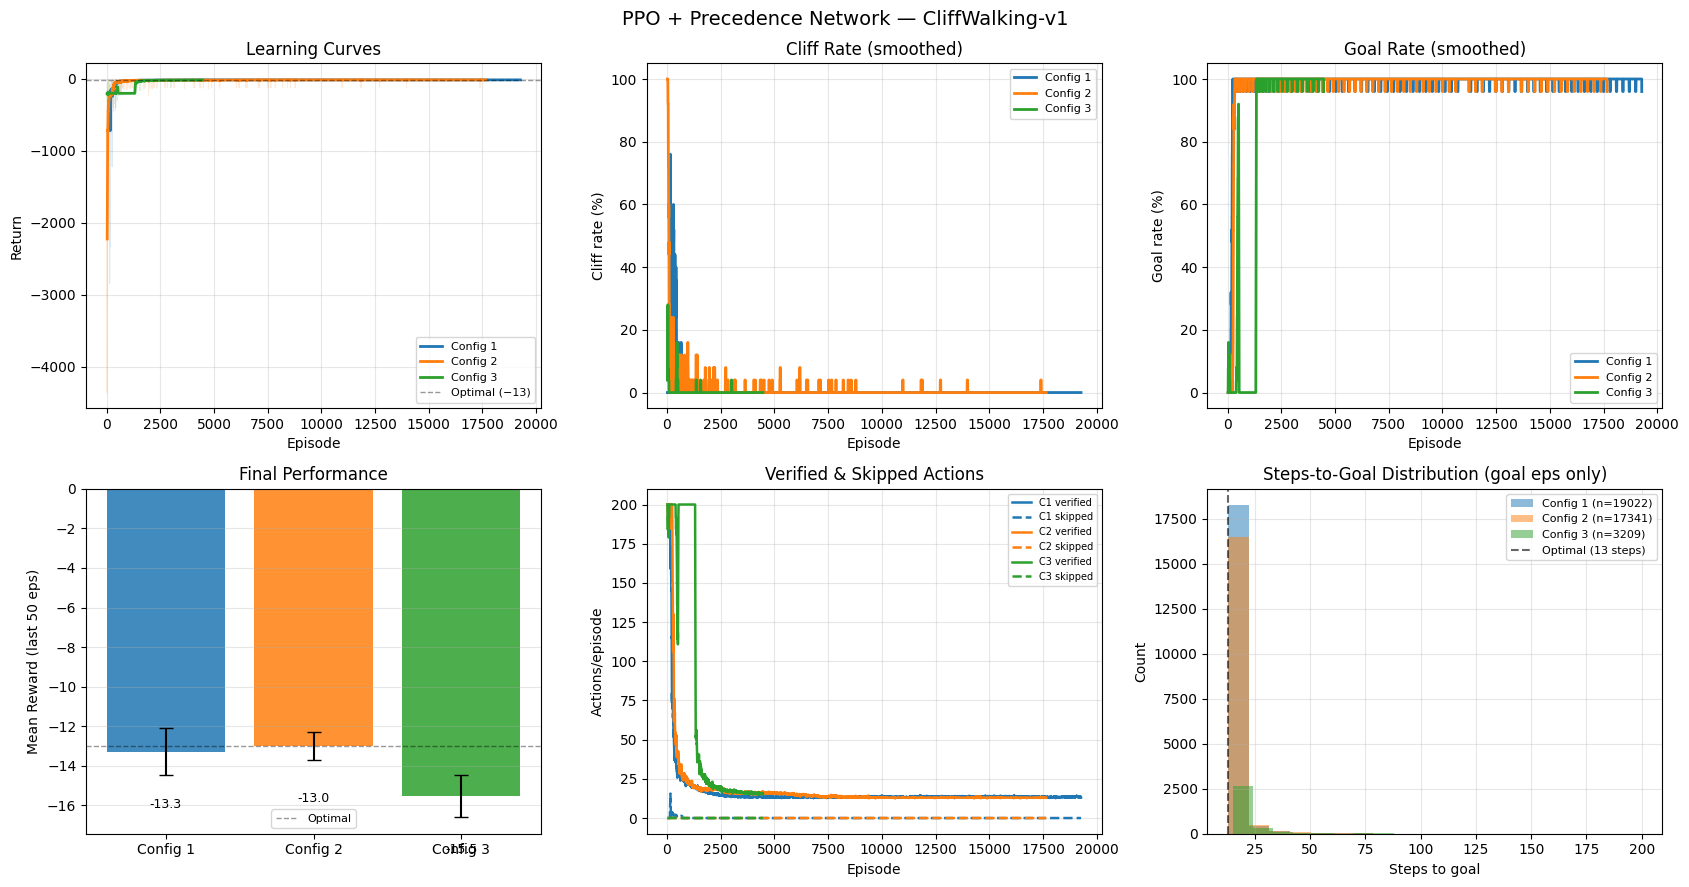

📊 Plot saved → plots_ppo_precedence_CliffWalking\ppo_precedence_all_configs.png


In [ ]:
COLORS        = ['#1f77b4', '#ff7f0e', '#2ca02c']
WINDOW_SMOOTH = 25
valid = [r for r in [results_c1, results_c2, results_c3] if r is not None]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle(f"PPO + Precedence Network — {ENV_NAME}", fontsize=14)

ax = axes[0, 0]
for res, col in zip(valid, COLORS):
    rw = np.array(res['rewards'])
    ax.plot(rw, alpha=0.15, color=col, linewidth=0.7)
    if len(rw) >= WINDOW_SMOOTH:
        ma = np.convolve(rw, np.ones(WINDOW_SMOOTH)/WINDOW_SMOOTH, mode='valid')
        ax.plot(np.arange(WINDOW_SMOOTH-1, len(rw)), ma,
                color=col, linewidth=2, label=f"Config {res['config']}")
ax.axhline(-13, color='k', linestyle='--', alpha=0.4, linewidth=1, label='Optimal (−13)')
ax.set_xlabel('Episode'); ax.set_ylabel('Return')
ax.set_title('Learning Curves'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[0, 1]
for res, col in zip(valid, COLORS):
    clf = np.array(res['cliff_flags'], dtype=float)
    if len(clf) >= WINDOW_SMOOTH:
        ma = np.convolve(clf, np.ones(WINDOW_SMOOTH)/WINDOW_SMOOTH, mode='valid')
        ax.plot(np.arange(WINDOW_SMOOTH-1, len(clf)), 100*ma,
                color=col, linewidth=2, label=f"Config {res['config']}")
ax.set_xlabel('Episode'); ax.set_ylabel('Cliff rate (%)')
ax.set_title('Cliff Rate (smoothed)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[0, 2]
for res, col in zip(valid, COLORS):
    gl = np.array(res['goal_flags'], dtype=float)
    if len(gl) >= WINDOW_SMOOTH:
        ma = np.convolve(gl, np.ones(WINDOW_SMOOTH)/WINDOW_SMOOTH, mode='valid')
        ax.plot(np.arange(WINDOW_SMOOTH-1, len(gl)), 100*ma,
                color=col, linewidth=2, label=f"Config {res['config']}")
ax.set_xlabel('Episode'); ax.set_ylabel('Goal rate (%)')
ax.set_title('Goal Rate (smoothed)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 0]
cfg_labels  = [f"Config {r['config']}" for r in valid]
final_means = [np.mean(r['rewards'][-50:]) for r in valid]
final_stds  = [np.std(r['rewards'][-50:])  for r in valid]
bars = ax.bar(cfg_labels, final_means, color=COLORS[:len(valid)],
              yerr=final_stds, capsize=5, alpha=0.85)
for bar, val in zip(bars, final_means):
    offset = 0.5 if val >= 0 else -3
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset,
            f"{val:.1f}", ha='center', va='bottom', fontsize=9)
ax.axhline(-13, color='k', linestyle='--', alpha=0.4, linewidth=1, label='Optimal')
ax.set_ylabel('Mean Reward (last 50 eps)')
ax.set_title('Final Performance'); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

ax = axes[1, 1]
for res, col in zip(valid, COLORS):
    vf = np.array(res['verified'], dtype=float)
    sk = np.array(res['skipped'],  dtype=float)
    if len(vf) >= WINDOW_SMOOTH:
        x    = np.arange(WINDOW_SMOOTH-1, len(vf))
        ma_v = np.convolve(vf, np.ones(WINDOW_SMOOTH)/WINDOW_SMOOTH, mode='valid')
        ma_s = np.convolve(sk, np.ones(WINDOW_SMOOTH)/WINDOW_SMOOTH, mode='valid')
        ax.plot(x, ma_v, color=col, linewidth=1.8,
                label=f"C{res['config']} verified")
        ax.plot(x, ma_s, color=col, linewidth=1.8, linestyle='--',
                label=f"C{res['config']} skipped")
ax.set_xlabel('Episode'); ax.set_ylabel('Actions/episode')
ax.set_title('Verified & Skipped Actions'); ax.legend(fontsize=7); ax.grid(alpha=0.3)

ax = axes[1, 2]
for res, col in zip(valid, COLORS):
    goal_steps = [res['steps'][i] for i in range(len(res['goal_flags']))
                  if res['goal_flags'][i]]
    if goal_steps:
        ax.hist(goal_steps, bins=20, alpha=0.5, color=col,
                label=f"Config {res['config']} (n={len(goal_steps)})")
ax.axvline(13, color='k', linestyle='--', alpha=0.6, label='Optimal (13 steps)')
ax.set_xlabel('Steps to goal'); ax.set_ylabel('Count')
ax.set_title('Steps-to-Goal Distribution (goal eps only)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(PLOT_DIR, 'ppo_precedence_all_configs.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Plot saved → {plot_path}")


## 14. Grid Heatmaps — Greedy Policy Visited States

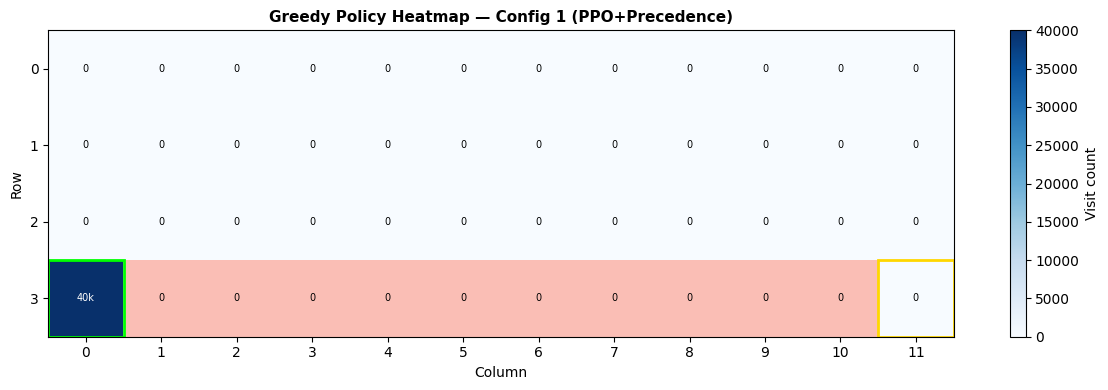

📊 Heatmap saved → plots_ppo_precedence_CliffWalking\heatmap_config1.png


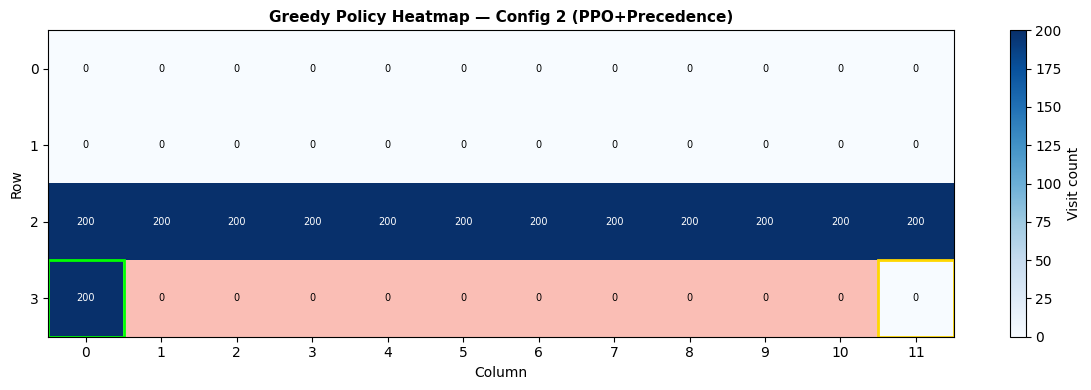

📊 Heatmap saved → plots_ppo_precedence_CliffWalking\heatmap_config2.png


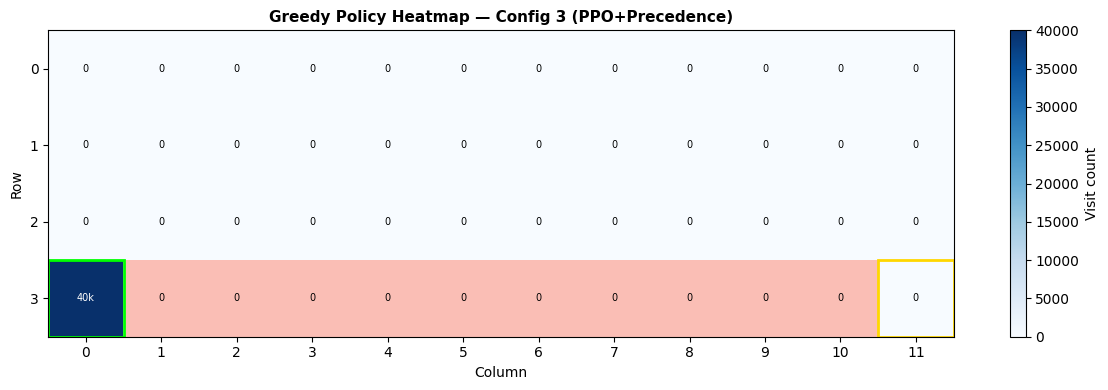

📊 Heatmap saved → plots_ppo_precedence_CliffWalking\heatmap_config3.png


In [ ]:
def plot_grid_heatmap_actor(actor, title, save_path, n_eval_eps=200):
    eval_env = gym.make(ENV_NAME)
    eval_env = TimeLimit(eval_env, max_episode_steps=MAX_STEPS_PER_EP)
    visits   = np.zeros(N_STATES, dtype=int)

    actor.eval()
    for ep in range(n_eval_eps):
        s, _ = eval_env.reset(seed=SEED + 500 + ep)
        done  = False
        while not done:
            visits[s] += 1
            s_oh = one_hot_state(s)
            with torch.no_grad():
                a = int(actor(
                    torch.FloatTensor(s_oh).unsqueeze(0).to(DEVICE)
                ).argmax(dim=-1).item())
            s, _, term, trunc, _ = eval_env.step(a)
            done = term or trunc
    eval_env.close()
    actor.train()

    grid = visits.reshape(GRID_ROWS, GRID_COLS)
    fig, ax = plt.subplots(figsize=(12, 4))
    im = ax.imshow(grid, cmap='Blues', aspect='auto')
    plt.colorbar(im, ax=ax, label='Visit count')

    for r in range(GRID_ROWS):
        for c in range(GRID_COLS):
            val = grid[r, c]
            ax.text(c, r, str(val) if val < 10000 else f"{val//1000}k",
                    ha='center', va='center', fontsize=7,
                    color='white' if val > grid.max()*0.6 else 'black')

    for c in range(1, 11):
        ax.add_patch(mpatches.Rectangle(
            (c-0.5, 2.5), 1, 1, fill=True, facecolor='tomato', alpha=0.4))
    ax.add_patch(mpatches.Rectangle((-0.5, 2.5), 1, 1,
        fill=False, edgecolor='lime', linewidth=2))
    ax.add_patch(mpatches.Rectangle((10.5, 2.5), 1, 1,
        fill=False, edgecolor='gold', linewidth=2))

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Column'); ax.set_ylabel('Row')
    ax.set_xticks(range(GRID_COLS)); ax.set_yticks(range(GRID_ROWS))
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"📊 Heatmap saved → {save_path}")


for res in valid:
    plot_grid_heatmap_actor(
        res['actor'],
        title=f"Greedy Policy Heatmap — Config {res['config']} (PPO+Precedence)",
        save_path=os.path.join(PLOT_DIR, f"heatmap_config{res['config']}.png"),
        n_eval_eps=200,
    )


## 15. Greedy Evaluation (10 episodes, mean reward)

In [ ]:
def greedy_eval_actor(actor, n_eval=10, seed_offset=999):
    eval_env = gym.make(ENV_NAME)
    eval_env = TimeLimit(eval_env, max_episode_steps=MAX_STEPS_PER_EP)
    rewards  = []
    actor.eval()
    for i in range(n_eval):
        s, _ = eval_env.reset(seed=SEED + seed_offset + i)
        ep_r, done = 0.0, False
        while not done:
            s_oh = one_hot_state(s)
            with torch.no_grad():
                a = int(actor(
                    torch.FloatTensor(s_oh).unsqueeze(0).to(DEVICE)
                ).argmax(dim=-1).item())
            s, r, term, trunc, _ = eval_env.step(a)
            done  = term or trunc
            ep_r += r
        rewards.append(ep_r)
    eval_env.close()
    actor.train()
    return rewards


print(f"\n{'='*75}")
print(f"  GREEDY EVALUATION (10 episodes, Actor argmax)")
print(f"{'='*75}")
for res in valid:
    ev = greedy_eval_actor(res['actor'])
    goal_rate = 100 * sum(r > -200 for r in ev) / len(ev)
    print(f"  Config {res['config']}: "
          f"mean={np.mean(ev):.2f}  std={np.std(ev):.2f}  "
          f"min={min(ev):.0f}  max={max(ev):.0f}  "
          f"goal_rate={goal_rate:.0f}%")



  GREEDY EVALUATION (10 episodes, Actor argmax)
  Config 1: mean=-20000.00  std=0.00  min=-20000  max=-20000  goal_rate=0%
  Config 2: mean=-13.00  std=0.00  min=-13  max=-13  goal_rate=100%
  Config 3: mean=-20000.00  std=0.00  min=-20000  max=-20000  goal_rate=0%


## 16. Verification Statistics Analysis

In [16]:
print(f"\n{'='*75}")
print(f"  VERIFICATION STATISTICS — PPO")
print(f"{'='*75}\n")

for res in valid:
    v      = res['verifier']
    config = res['config']
    if v is None:
        continue
    total = v.total_checked
    print(f"Config {config}:")
    print(f"  Total WM checks           : {total:,}")
    print(f"  Safety-rejected           : {v.safety_rejected:,}  "
          f"({100*v.safety_rejected/max(total,1):.1f}%)")
    print(f"  Lookahead-rejected        : {v.lookahead_rejected:,}  "
          f"({100*v.lookahead_rejected/max(total,1):.1f}%)")
    print(f"  No safe alternative found : {v.no_safe_alt:,}  "
          f"({100*v.no_safe_alt/max(total,1):.1f}%)")
    vf = np.array(res['verified'])
    sk = np.array(res['skipped'])
    print(f"  Avg verified actions/ep   : {vf.mean():.2f}")
    print(f"  Avg skipped  actions/ep   : {sk.mean():.2f}")
    print()



  VERIFICATION STATISTICS — PPO

Config 1:
  Total WM checks           : 370,405
  Safety-rejected           : 18,258  (4.9%)
  Lookahead-rejected        : 33,355  (9.0%)
  No safe alternative found : 1,208  (0.3%)
  Avg verified actions/ep   : 16.54
  Avg skipped  actions/ep   : 0.06

Config 2:
  Total WM checks           : 329,321
  Safety-rejected           : 8,680  (2.6%)
  Lookahead-rejected        : 641  (0.2%)
  No safe alternative found : 0  (0.0%)
  Avg verified actions/ep   : 18.12
  Avg skipped  actions/ep   : 0.00

Config 3:
  Total WM checks           : 489,821
  Safety-rejected           : 83,629  (17.1%)
  Lookahead-rejected        : 86,192  (17.6%)
  No safe alternative found : 0  (0.0%)
  Avg verified actions/ep   : 71.56
  Avg skipped  actions/ep   : 0.00



## 17. Save Checkpoints & Results

In [17]:
def save_results(results_list, filename):
    save_data = {}
    for res in results_list:
        if res is None:
            continue
        cfg = res['config']
        rw  = res['rewards']
        gl  = res['goal_flags']
        clf = res['cliff_flags']
        st  = res['steps']
        goal_steps = [st[i] for i in range(len(gl)) if gl[i]]

        save_data[f"config_{cfg}"] = {
            'rewards'              : [float(r) for r in rw],
            'cliff_flags'          : [int(c)   for c in clf],
            'goal_flags'           : [int(g)   for g in gl],
            'steps'                : [int(s)   for s in st],
            'verified'             : [int(v)   for v in res['verified']],
            'skipped'              : [int(s)   for s in res['skipped']],
            'final_reward_mean'    : float(np.mean(rw[-50:])),
            'final_reward_std'     : float(np.std(rw[-50:])),
            'final_cliff_pct'      : float(100 * np.mean(clf[-50:])),
            'final_goal_pct'       : float(100 * np.mean(gl[-50:])),
            'avg_steps_to_goal'    : float(np.mean(goal_steps[-50:])) if goal_steps else None,
            'total_goal_episodes'  : int(sum(gl)),
            'total_cliff_episodes' : int(sum(clf)),
        }
        v = res.get('verifier')
        if v is not None:
            save_data[f"config_{cfg}"]['verifier'] = {
                'total_checked'      : v.total_checked,
                'safety_rejected'    : v.safety_rejected,
                'lookahead_rejected' : v.lookahead_rejected,
                'no_safe_alt'        : v.no_safe_alt,
            }

    out_path = os.path.join(CHECKPOINT_DIR, filename)
    with open(out_path, 'w') as f:
        json.dump(save_data, f, indent=4)
    print(f"✅ Results saved → {out_path}")


save_results(
    [results_c1, results_c2, results_c3],
    'ppo_precedence_cliffwalking_results.json'
)

for res in valid:
    cfg      = res['config']
    pth_path = os.path.join(CHECKPOINT_DIR, f"ppo_config{cfg}.pth")
    torch.save({
        'actor'          : res['actor'].state_dict(),
        'critic'         : res['critic'].state_dict(),
        'config'         : cfg,
        'n_states'       : N_STATES,
        'n_actions'      : N_ACTIONS,
        'use_precedence' : res['use_precedence'],
        'verify_strategy': res['verify_strategy'],
        'hidden_sizes'   : HIDDEN_SIZES,
    }, pth_path)
    print(f"✅ Model Config {cfg} saved → {pth_path}")

print(f"\n✅ All done!")
print(f"  Checkpoints : {CHECKPOINT_DIR}/")
print(f"  Plots       : {PLOT_DIR}/")


✅ Results saved → checkpoints_ppo_precedence_CliffWalking\ppo_precedence_cliffwalking_results.json
✅ Model Config 1 saved → checkpoints_ppo_precedence_CliffWalking\ppo_config1.pth
✅ Model Config 2 saved → checkpoints_ppo_precedence_CliffWalking\ppo_config2.pth
✅ Model Config 3 saved → checkpoints_ppo_precedence_CliffWalking\ppo_config3.pth

✅ All done!
  Checkpoints : checkpoints_ppo_precedence_CliffWalking/
  Plots       : plots_ppo_precedence_CliffWalking/
